Πέτρος Ματσούκης: 1115202100099, Γιώργος Κορύλλος: 1115202100069

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
x = [1, 2, 3, 4, 3, 2, 1]
y = [1, 3, 2, 3, 2, 2]
from tslearn.metrics import lcss, lcss_path

lcss_score = lcss(x, y)
# Or, if the path is also an important information:
path, lcss_score = lcss_path(x, y)
print(path)
print(lcss_score)

[(0, 0), (1, 1), (2, 2), (4, 3), (5, 4), (6, 5)]
1.0


In [ ]:
import pandas as pd
import numpy as np
import string
import nltk
nltk.download('punkt')
import pickle
import matplotlib.pyplot as plt
from matplotlib import colors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn import svm
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, make_scorer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial.distance import cosine
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
!pip install transformers
import transformers
from transformers import pipeline
!pip install langdetect
from langdetect import detect
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
import ast
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
reviews_february_2019 = '/content/drive/MyDrive/2019/febrouary/reviews.csv'
reviews_march_2019 = '/content/drive/MyDrive/2019/march/reviews.csv'
reviews_april_2019 = '/content/drive/MyDrive/2019/april/reviews.csv'

columns = ['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments']

#function to detect language to every row of a DataFrame
def detect_language(text):
  try:
    return detect(text)
  except:
    return None

reviews_february_2019_df = pd.read_csv(reviews_february_2019)
reviews_march_2019_df = pd.read_csv(reviews_march_2019)
reviews_april_2019_df = pd.read_csv(reviews_april_2019)

reviews_2019_df = pd.concat([reviews_february_2019_df, reviews_march_2019_df, reviews_april_2019_df], ignore_index=True)

#keep first 100000 rows
reviews_2019_df = reviews_2019_df.iloc[:100000]

#convert all upper characters to lower and remove punctuation
reviews_2019_df['comments'] = reviews_2019_df['comments'].astype(str)
reviews_2019_df['comments'] = reviews_2019_df['comments'].str.lower()
reviews_2019_df['comments'] = reviews_2019_df['comments'].str.translate(str.maketrans(string.punctuation, ' '*len(string.punctuation)))
reviews_2019_df['comments'] = reviews_2019_df['comments'].str.split()

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('words')

#delete stopwords
stop_words = set(stopwords.words('english'))
reviews_2019_df['comments'] = reviews_2019_df['comments'].apply(lambda comm: [word for word in comm if word not in stop_words])

#lemmatize all words
lemmatizer = WordNetLemmatizer()
reviews_2019_df['comments'] = reviews_2019_df['comments'].apply(lambda comm: [lemmatizer.lemmatize(word) for word in comm])

#remove words with less than one letter
reviews_2019_df['comments'] = reviews_2019_df['comments'].apply(lambda comm: ' '.join(word for word in comm if len(word) > 1))

#split again because of join above
reviews_2019_df['comments'] = reviews_2019_df['comments'].str.split()

#keep only alphabetic characters
reviews_2019_df['comments'] = reviews_2019_df['comments'].apply(lambda comm: [item for item in comm if item.isalpha()])
reviews_2019_df['comments'] = reviews_2019_df['comments'].astype(str)


#remove rows that doesn't contain an english letter
reviews_2019_df = reviews_2019_df[reviews_2019_df['comments'].str.contains(r'[a-zA-Z]', na=False)]

#remove all rows that have nothing
reviews_2019_df = reviews_2019_df[reviews_2019_df['comments'].apply(lambda comm: len(comm) > 0)]

#load positive and negative words from txt files
with open('/content/drive/MyDrive/positive.txt', 'r') as file:
  positive_words = set(file.read().splitlines())
with open('/content/drive/MyDrive/negative.txt', 'r') as file:
  negative_words = set(file.read().splitlines())

#lists for every row of DataFrame based on positive and negative words from txt files
positive_rows = []
negative_rows = []
neutral_rows = []

for index, row in reviews_2019_df.iterrows():
  #for each row, create a set with all its words
  comment_words = set(ast.literal_eval(row['comments']))
  length_pos = len(comment_words.intersection(positive_words))
  length_neg = len(comment_words.intersection(negative_words))
  if (length_pos == 0) and (length_neg == 0): #if there are words from comment_words in positive_words
    neutral_rows.append(row)
  elif length_pos > length_neg: #if there are words from comment_words in negative_words
    positive_rows.append(row)
  else:
    negative_rows.append(row)

#create DataFrames from the lists
positive_df = pd.DataFrame(positive_rows)
positive_df = positive_df.iloc[:400]

negative_df = pd.DataFrame(negative_rows)
negative_df = negative_df.iloc[:2495]

neutral_df = pd.DataFrame(neutral_rows)
neutral_df = neutral_df.iloc[:1800]

reviews_2019_df = pd.concat([positive_df, negative_df, neutral_df], ignore_index=True)

reviews_2019_df = reviews_2019_df.iloc[:4690]

#apply the function that detects language to 'comments'
reviews_2019_df['language'] = reviews_2019_df['comments'].apply(detect_language)

#keep rows that their language is English
reviews_2019_df = reviews_2019_df[reviews_2019_df['language'] == 'en']

#remove column 'language' because we don't need it anymore
reviews_2019_df = reviews_2019_df.drop(columns=['language'])

#save cleaned data to a train file
reviews_2019_df.to_csv('train_2019.csv', index=False)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


#Ερώτημα 1

In [ ]:
#load data
df = pd.read_csv('train_2019.csv')

#train will have 80% of data, test will have 20%
df_test, df_train = train_test_split(df, test_size = 0.8, random_state = 42)

#save test data(data without analysis) to a tsv file because we will need it later for testing classifiers in query 2
df_test.to_csv('test_2019.tsv', index = False, sep = '\t')

In [ ]:
#create sentiment analysis pipeline with the appropriate model
sentiment_analysis = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")

#load cleaned data
df_train = pd.read_csv('train_2019.csv')

#remove brackets, quotation marks and comma from 'comments' column
df_train['comments'] = df_train['comments'].str.replace('\'', '').str.replace('[', '').str.replace(']', '').str.replace(',', '')

#apply created pipeline to 'comments' column so we get sentiment analysis
sentiment = sentiment_analysis(df_train['comments'].tolist())

#create column 'sentiment' and put it into the DataFrame
df_train['sentiment'] = [result['label'] for result in sentiment]

#keep columns needed
df_train = df_train[['id', 'comments', 'sentiment']]

#save results to 'sentiment_2019.csv'
df_train.to_csv('sentiment_2019.csv', index=False)

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
#load data after it's analyzed
df_sentiment = pd.read_csv('sentiment_2019.csv')

#train will have 80% of data, test will have 20%
df_test, df_train = train_test_split(df_sentiment, test_size = 0.8, random_state = 42)

#save train data(data with analysis) to a tsv file
df_train.to_csv('train_2019.tsv', index = False, sep = '\t')

#save test data(data with analysis) to a csv file because we will need it for Cross Validation in query 2
df_test.to_csv('sentiment_2019_test.csv', index = False)

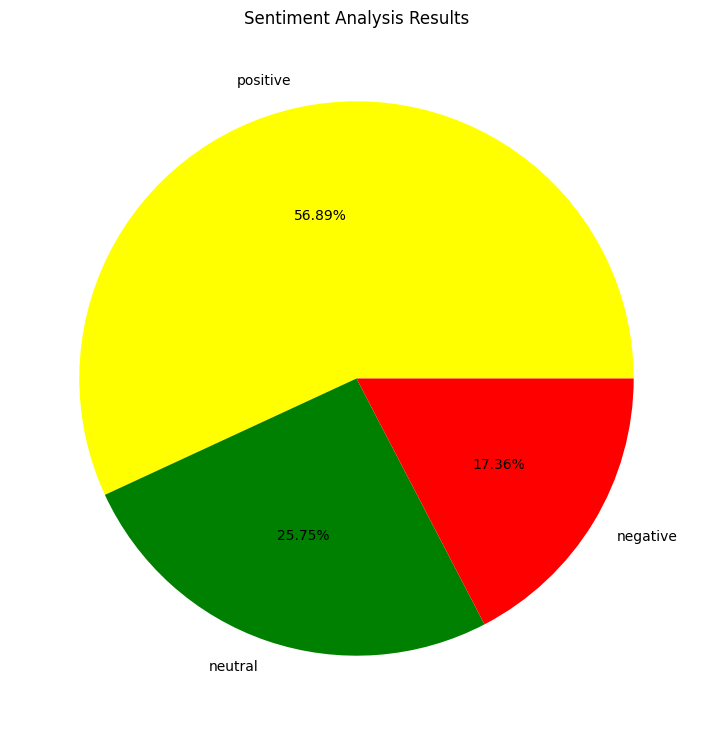

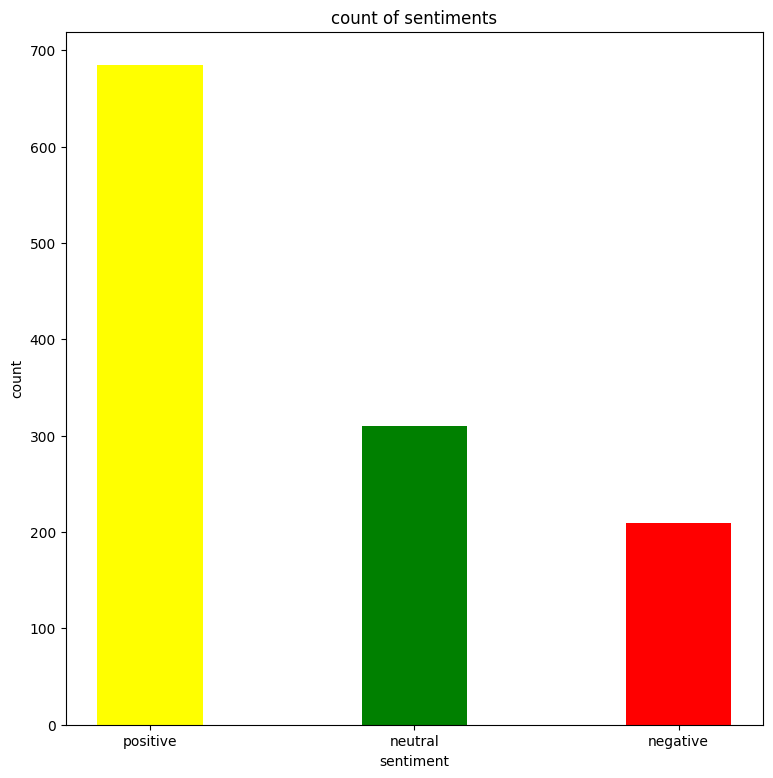

In [ ]:
#load csv with sentiment
df_sentiment = pd.read_csv('sentiment_2019.csv')

#count the amount of each sentiment
sentiment_counts = df_sentiment['sentiment'].value_counts()

#create pie diagram of sentiment percentages
plt.figure(figsize=(9, 9))
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%.2f%%', colors=['yellow', 'green', 'red'])
plt.title('Sentiment Analysis Results')
plt.show()

#count the amount of each sentiment
sentiment_counts = df_sentiment['sentiment'].value_counts()

#make plot
plt.figure(figsize=(9, 9))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['yellow', 'green', 'red'], width = 0.4)
plt.xlabel('sentiment')
plt.ylabel('count')
plt.title('count of sentiments')

#save plot
plt.savefig('question_1.png')

#Ερώτημα 2

In [ ]:
#creation of TF-IDF matrix with data from file 'train_2019.tsv'

#load data from 'train_2019.tsv'
df_train = pd.read_csv('train_2019.tsv', sep = '\t')

#keep 'comments' column
comments = df_train['comments']

#create TfidfVectorizer
vectorizer = TfidfVectorizer()

#transform data from column 'comments' and this will be the tfidf_matrix
tfidf_matrix = vectorizer.fit_transform(comments)

#save TfidfVectorizer to a pickle file named 'tfidf_vectorizer_2019.pkl'
with open('tfidf_vectorizer_2019.pkl', 'wb') as file:
  pickle.dump(vectorizer, file)

In [ ]:
#creation of wordembeddings with data of file 'train_2019.tsv'

#load data from 'train_2019.tsv'
df_train = pd.read_csv('train_2019.tsv', sep = '\t')

#keep 'comments' column
comments = df_train['comments']

#tokenize data from column 'comments'
tokenized_comments = [word_tokenize(com) for com in comments]

#create a Word2Vec model
model = Word2Vec(vector_size=100, window=5, min_count=1, workers=4)

model.build_vocab(tokenized_comments)
model.train(tokenized_comments, total_examples=model.corpus_count, epochs=model.epochs)

#save Word2Vec model to a pickle file named 'word2vec_model_2019.pkl'
with open('word2vec_model_2019.pkl', 'wb') as file:
  pickle.dump(model, file)

In [ ]:
#SVM with TF-IDF

#load data from 'train_2019.tsv'
df_train = pd.read_csv('train_2019.tsv', sep = '\t')

#keep 'sentiment' column
sentiment = df_train['sentiment']

#split
train_1, val_1, train_2, val_2 = train_test_split(tfidf_matrix, sentiment, test_size=0.2, random_state=42)

#train SVM classifier
clf = SVC(C=1.0, kernel='linear', gamma='scale')
clf.fit(train_1, train_2)

#print validation accuracy
print('Validation accuracy =', clf.score(val_1, val_2))

#load data from 'test_2019.tsv' transform comments to TF-IDF matrix, make predictions
df_test = pd.read_csv('test_2019.tsv', sep = '\t')
df_comm = df_test['comments']

#transform comments
with open('tfidf_vectorizer_2019.pkl', 'rb') as file:
  vectorizer = pickle.load(file)
test = vectorizer.transform(df_comm)

#make predictions
df_test['sentiment'] = clf.predict(test)

#save data with predictions
df_test.to_csv('predict_svm_tfidf.csv', index=False)

Validation accuracy = 0.7512953367875648


In [ ]:
#SVM with wordembeddings

#load Word2Vec model
with open('word2vec_model_2019.pkl', 'rb') as file:
  model = pickle.load(file)

#convert tokenized comments into vectors
vectorized_comments = [model.wv[comment] for comment in tokenized_comments]

#take the average of vectors for every comment to get a single vector for each comment
vectorized_comments = [np.mean(comment, axis=0) for comment in vectorized_comments]

#load data from 'train_2019.tsv'
df_train = pd.read_csv('train_2019.tsv', sep='\t')

#take 'sentiment' column
sentiment = df_train['sentiment']

#split
train_1, val_1, train_2, val_2 = train_test_split(vectorized_comments, sentiment, test_size=0.2, random_state=42)

#train SVM classifier
clf = SVC(C=1.0, kernel='linear', gamma='scale')
clf.fit(train_1, train_2)

#print validation accuracy
accuracy = clf.score(val_1, val_2)
print('Validation Accuracy:', accuracy)

#load data from 'test_2019.tsv'
df_test = pd.read_csv('test_2019.tsv', sep='\t')
df_test['comments'] = df_test['comments'].str.replace('\'', '').str.replace('[', '').str.replace(']', '').str.replace(',', '')

#take the 'comments' column
comments = df_test['comments']

#list so we can save word vectors
word_vectors_list = []

#go to every comment
for comment in comments:
  words = comment.split()
  word_vectors = [model.wv[word] for word in words if word in model.wv]
  if word_vectors:
    word_vectors_list.append(np.mean(word_vectors, axis=0))
  else:
    word_vectors_list.append(np.zeros(model.vector_size))

#convert list with word vectors to a numpy array
word_vectors_array = np.array(word_vectors_list)

#make sure the array is 2D
#if word_vectors_list.ndim == 1:
    #word_vectors_list = word_vectors_list.reshape(1, -1)

#use trained SVM classifier to predict sentiments on 'test_2019.tsv'
predictions = clf.predict(word_vectors_array)

#add predictions in DataFrame
df_test['sentiment'] = predictions

#save DataFrame to a new csv file
df_test.to_csv('predict_svm_word.csv', index=False)

Validation Accuracy: 0.6424870466321243


In [ ]:
#10-fold Cross Validation with TF-IDF for SVM

#load data from 'sentiment_2019_test.csv'
df = pd.read_csv('sentiment_2019_test.csv')

#transform comments
with open('tfidf_vectorizer_2019.pkl', 'rb') as file:
  vectorizer = pickle.load(file)

vec_comments = vectorizer.transform(df['comments'])
labels = LabelEncoder().fit_transform(df['sentiment'])

#initialize classifier and strategy for Cross Validation
clf = SVC(C=1.0, kernel='linear', gamma='scale')
cv = StratifiedKFold(n_splits=10)

#create dictionary named metrics and their scoring functions
metrics = {
  'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
  'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
  'F_Measure': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
  'Accuracy': 'accuracy'
}

#compute all scores for Cross Validation
scores = {metric: cross_val_score(clf, vec_comments, labels, cv=cv, scoring=scorer) for metric, scorer in metrics.items()}

#create DataFrame with all scores and print it
df_scores = pd.DataFrame(scores)
print(df_scores)

#print all metrics by average
print("\nBy average:")
for metric, score in scores.items():
    print(f'{metric}: {score.mean()}')

   Precision    Recall  F_Measure  Accuracy
0   0.585648  0.708333   0.633788  0.708333
1   0.696759  0.708333   0.666206  0.708333
2   0.810417  0.708333   0.667508  0.708333
3   0.745614  0.708333   0.670263  0.708333
4   0.828947  0.750000   0.721354  0.750000
5   0.820238  0.791667   0.775641  0.791667
6   0.528409  0.625000   0.521429  0.625000
7   0.810417  0.708333   0.670815  0.708333
8   0.810417  0.708333   0.654446  0.708333
9   0.848438  0.833333   0.823700  0.833333

By average:
Precision: 0.7485303497063366
Recall: 0.725
F_Measure: 0.6805151079737426
Accuracy: 0.725


In [ ]:
#10-fold Cross Validation with wordembeddings for SVM

#load data from 'sentiment_2019_test.csv'
df = pd.read_csv('sentiment_2019_test.csv')

with open('word2vec_model_2019.pkl', 'rb') as file:
  vectorizer = pickle.load(file)

comments = df['comments']
labels = LabelEncoder().fit_transform(df['sentiment'])

#create list to save embeddings
embeddings = []

#go to every comment
for comment in comments:
  words = comment.split()
  #initialize list to save word embeddings for each comment
  word_embeddings_list = []
  #go to every word for each comment
  for word in words:
    #check if word is in vocabulary of word embeddings
    if word in vectorizer.wv:
      #append word's embedding to list with embeddings of each comment
      word_embeddings_list.append(vectorizer.wv[word])

  if word_embeddings_list:
    #compute mean embedding of words in each comment
    mean_embedding = np.mean(word_embeddings_list, axis=0)
  else:
    #create a vector with zeroes if comment has not words in vocabulary
    mean_embedding = np.zeros(vectorizer.wv.vector_size)

  #append mean embedding of each comment to list
  embeddings.append(mean_embedding)

#convert list with embeddings to a numpy array
embeddings_array = np.array(embeddings)

#initialize classifier and strategy for Cross Validation
clf= SVC(C=1.0, kernel='linear', gamma='scale')
cv = StratifiedKFold(n_splits=10)

#create dictionary named metrics and their scoring functions
metrics = {
  'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
  'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
  'F_Measure': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
  'Accuracy': 'accuracy'
}

#compute all scores for Cross Validation
scores = {metric: cross_val_score(clf, embeddings_array, labels, cv=cv, scoring=scorer) for metric, scorer in metrics.items()}

#create DataFrame with all scores and print it
df_scores = pd.DataFrame(scores)
print(df_scores)

#print all metrics by average
print("\nBy average:")
for metric, score in scores.items():
    print(f'{metric}: {score.mean()}')

   Precision    Recall  F_Measure  Accuracy
0   0.352083  0.541667   0.426768  0.541667
1   0.529762  0.625000   0.530882  0.625000
2   0.497917  0.625000   0.532828  0.625000
3   0.477083  0.625000   0.526768  0.625000
4   0.477083  0.625000   0.526768  0.625000
5   0.557870  0.708333   0.620968  0.708333
6   0.306159  0.541667   0.391204  0.541667
7   0.477083  0.625000   0.526768  0.625000
8   0.414583  0.583333   0.476768  0.583333
9   0.557073  0.708333   0.623291  0.708333

By average:
Precision: 0.46466978578871176
Recall: 0.6208333333333332
F_Measure: 0.518301106353763
Accuracy: 0.6208333333333332


In [ ]:
#Random Forests with TF-IDF

#load data from 'train_2019.tsv'
df_train = pd.read_csv('train_2019.tsv', sep = '\t')

#keep 'sentiment' column
sentiment = df_train['sentiment']

#split
train_1, val_1, train_2, val_2 = train_test_split(tfidf_matrix, sentiment, test_size=0.2, random_state=42)

#train Random Forest classifier
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(train_1, train_2)

#print validation accuracy
print('Validation accuracy =', clf_rf.score(val_1, val_2))

#load data from 'test_2019.tsv' transform comments to TF-IDF matrix, make predictions
df_test = pd.read_csv('test_2019.tsv', sep = '\t')
df_comm = df_test['comments']

#transform comments
with open('tfidf_vectorizer_2019.pkl', 'rb') as file:
  vectorizer = pickle.load(file)
test = vectorizer.transform(df_comm)

#make predictions
df_test['sentiment'] = clf_rf.predict(test)

#save data with predictions
df_test.to_csv('predict_rf_tfidf.csv', index=False)

Validation accuracy = 0.7098445595854922


In [ ]:
#Random Forests with wordembeddings

#load Word2Vec model
with open('word2vec_model_2019.pkl', 'rb') as file:
  model = pickle.load(file)

#convert tokenized comments into vectors
vectorized_comments = [model.wv[comment] for comment in tokenized_comments]

#take the average of vectors for every comment to get a single vector for each comment
vectorized_comments = [np.mean(comment, axis=0) for comment in vectorized_comments]

#load data from 'train_2019.tsv'
df_train = pd.read_csv('train_2019.tsv', sep='\t')

#take 'sentiment' column
sentiment = df_train['sentiment']

#split
train_1, val_1, train_2, val_2 = train_test_split(vectorized_comments, sentiment, test_size=0.2, random_state=42)

#train Random Forest classifier
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(train_1, train_2)

#print validation accuracy
accuracy = clf_rf.score(val_1, val_2)
print('Validation Accuracy:', accuracy)

#load data from 'test_2019.tsv'
df_test = pd.read_csv('test_2019.tsv', sep='\t')
df_test['comments'] = df_test['comments'].str.replace('\'', '').str.replace('[', '').str.replace(']', '').str.replace(',', '')

#take the 'comments' column
comments = df_test['comments']

#list so we can save word vectors
word_vectors_list = []

#go to every comment
for comment in comments:
  words = comment.split()
  word_vectors = [model.wv[word] for word in words if word in model.wv]
  if word_vectors:
    word_vectors_list.append(np.mean(word_vectors, axis=0))
  else:
    word_vectors_list.append(np.zeros(model.vector_size))

#convert list with word vectors to a numpy array
word_vectors_array = np.array(word_vectors_list)

#make sure the array is 2D
#if word_vectors_list.ndim == 1:
    #word_vectors_list = word_vectors_list.reshape(1, -1)

#use trained SVM classifier to predict sentiments on 'test_2019.tsv'
predictions = clf_rf.predict(word_vectors_array)

#add predictions in DataFrame
df_test['sentiment'] = predictions

#save DataFrame to a new csv file
df_test.to_csv('predict_rf_word.csv', index=False)

Validation Accuracy: 0.6373056994818653


In [ ]:
#10-fold Cross Validation with TF-IDF for Random Forests

#load data from 'sentiment_2019_test.csv'
df = pd.read_csv('sentiment_2019_test.csv')

#transform comments
with open('tfidf_vectorizer_2019.pkl', 'rb') as file:
  vectorizer = pickle.load(file)

vec_comments = vectorizer.transform(df['comments'])
labels = LabelEncoder().fit_transform(df['sentiment'])

#initialize classifier and strategy for Cross Validation
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=10)

#create dictionary named metrics and their scoring functions
metrics = {
  'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
  'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
  'F_Measure': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
  'Accuracy': 'accuracy'
}

#compute all scores for Cross Validation
scores = {metric: cross_val_score(clf_rf, vec_comments, labels, cv=cv, scoring=scorer) for metric, scorer in metrics.items()}

#create DataFrame with all scores and print it
df_scores = pd.DataFrame(scores)
print(df_scores)

#print all metrics by average
print("\nBy average:")
for metric, score in scores.items():
    print(f'{metric}: {score.mean()}')

   Precision    Recall  F_Measure  Accuracy
0   0.662281  0.750000   0.683160  0.750000
1   0.640686  0.666667   0.634722  0.666667
2   0.699405  0.666667   0.667901  0.666667
3   0.872549  0.833333   0.825694  0.833333
4   0.756944  0.708333   0.688402  0.708333
5   0.784127  0.750000   0.736951  0.750000
6   0.642857  0.583333   0.514297  0.583333
7   0.626961  0.583333   0.571068  0.583333
8   0.849537  0.791667   0.777218  0.791667
9   0.864583  0.833333   0.834821  0.833333

By average:
Precision: 0.7399930483889461
Recall: 0.7166666666666666
F_Measure: 0.6934235007860285
Accuracy: 0.7166666666666666


In [ ]:
#10-fold Cross Validation with wordembeddings for Random Forests

#load data from 'sentiment_2019_test.csv'
df = pd.read_csv('sentiment_2019_test.csv')

with open('word2vec_model_2019.pkl', 'rb') as file:
  vectorizer = pickle.load(file)

comments = df['comments']
labels = LabelEncoder().fit_transform(df['sentiment'])

#create list to save embeddings
embeddings = []

#go to every comment
for comment in comments:
  words = comment.split()
  #initialize list to save word embeddings for each comment
  word_embeddings_list = []
  #go to every word for each comment
  for word in words:
    #check if word is in vocabulary of word embeddings
    if word in vectorizer.wv:
      #append word's embedding to list with embeddings of each comment
      word_embeddings_list.append(vectorizer.wv[word])

  if word_embeddings_list:
    #compute mean embedding of words in each comment
    mean_embedding = np.mean(word_embeddings_list, axis=0)
  else:
    #create a vector with zeroes if comment has not words in vocabulary
    mean_embedding = np.zeros(vectorizer.wv.vector_size)

  #append mean embedding of each comment to list
  embeddings.append(mean_embedding)

#convert list with embeddings to a numpy array
embeddings_array = np.array(embeddings)

#initialize classifier and strategy for Cross Validation
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=10)

#create dictionary named metrics and their scoring functions
metrics = {
    'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
    'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
    'F_Measure': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
    'Accuracy': 'accuracy'
}

#compute all scores for Cross Validation
scores = {metric: cross_val_score(clf_rf, embeddings_array, labels, cv=cv, scoring=scorer) for metric, scorer in metrics.items()}

#create DataFrame with all scores and print it
df_scores = pd.DataFrame(scores)
print(df_scores)

#print all metrics by average
print("\nBy average:")
for metric, score in scores.items():
    print(f'{metric}: {score.mean()}')

   Precision    Recall  F_Measure  Accuracy
0   0.872549  0.833333   0.824423  0.833333
1   0.551879  0.583333   0.550902  0.583333
2   0.655556  0.666667   0.654762  0.666667
3   0.761285  0.708333   0.687435  0.708333
4   0.629167  0.625000   0.625000  0.625000
5   0.720833  0.708333   0.712121  0.708333
6   0.614379  0.625000   0.601389  0.625000
7   0.694444  0.666667   0.638402  0.666667
8   0.661905  0.666667   0.662598  0.666667
9   0.812500  0.791667   0.787165  0.791667

By average:
Precision: 0.6974496673669468
Recall: 0.6875000000000001
F_Measure: 0.6744196785821739
Accuracy: 0.6875000000000001


In [ ]:
#KNN with TF-IDF

#load data from 'train_2019.tsv'
df_train = pd.read_csv('train_2019.tsv', sep = '\t')

#keep 'sentiment' column
sentiment = df_train['sentiment']

#split
train_1, val_1, train_2, val_2 = train_test_split(tfidf_matrix, sentiment, test_size=0.2, random_state=42)

#train KNN classifier
clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_knn.fit(train_1, train_2)

#print validation accuracy
print('Validation accuracy =', clf_knn.score(val_1, val_2))

#load data from 'test_2019.tsv' transform comments to TF-IDF matrix, make predictions
df_test = pd.read_csv('test_2019.tsv', sep = '\t')
df_comm = df_test['comments']

#transform comments
with open('tfidf_vectorizer_2019.pkl', 'rb') as file:
  vectorizer = pickle.load(file)
test = vectorizer.transform(df_comm)

#make predictions
df_test['sentiment'] = clf_knn.predict(test)

#save data with predictions
df_test.to_csv('predict_knn_tfidf.csv', index=False)

Validation accuracy = 0.694300518134715


In [ ]:
#KNN with wordembeddings

#load Word2Vec model
with open('word2vec_model_2019.pkl', 'rb') as file:
  model = pickle.load(file)

#convert tokenized comments into vectors
vectorized_comments = [model.wv[comment] for comment in tokenized_comments]

#take the average of vectors for every comment to get a single vector for each comment
vectorized_comments = [np.mean(comment, axis=0) for comment in vectorized_comments]

#load data from 'train_2019.tsv'
df_train = pd.read_csv('train_2019.tsv', sep='\t')

#take 'sentiment' column
sentiment = df_train['sentiment']

#split
train_1, val_1, train_2, val_2 = train_test_split(vectorized_comments, sentiment, test_size=0.2, random_state=42)

#train KNN classifier
clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_knn.fit(train_1, train_2)

#print validation accuracy
accuracy = clf_knn.score(val_1, val_2)
print('Validation Accuracy:', accuracy)

#load data from 'test_2019.tsv'
df_test = pd.read_csv('test_2019.tsv', sep='\t')
df_test['comments'] = df_test['comments'].str.replace('\'', '').str.replace('[', '').str.replace(']', '').str.replace(',', '')

#take the 'comments' column
comments = df_test['comments']

#list so we can save word vectors
word_vectors_list = []

#go to every comment
for comment in comments:
    words = comment.split()
    word_vectors = [model.wv[word] for word in words if word in model.wv]
    if word_vectors:
        word_vectors_list.append(np.mean(word_vectors, axis=0))
    else:
        word_vectors_list.append(np.zeros(model.vector_size))

#convert list with word vectors to a numpy array
word_vectors_array = np.array(word_vectors_list)

#make sure the array is 2D
#if word_vectors_list.ndim == 1:
    #word_vectors_list = word_vectors_list.reshape(1, -1)

#use trained SVM classifier to predict sentiments on 'test_2019.tsv'
predictions = clf_knn.predict(word_vectors_array)

#add predictions in DataFrame
df_test['sentiment'] = predictions

#save DataFrame to a new csv file
df_test.to_csv('predict_knn_word.csv', index=False)

Validation Accuracy: 0.616580310880829


In [ ]:
#10-fold Cross Validation with TF-IDF for KNN

#load data from 'sentiment_2019_test.csv'
df = pd.read_csv('sentiment_2019_test.csv')

#transform comments
with open('tfidf_vectorizer_2019.pkl', 'rb') as file:
  vectorizer = pickle.load(file)

vec_comments = vectorizer.transform(df['comments'])
labels = LabelEncoder().fit_transform(df['sentiment'])

#train KNN classifier
clf_knn = KNeighborsClassifier(n_neighbors=5)
cv = StratifiedKFold(n_splits=10)

#create dictionary named metrics and their scoring functions
metrics = {
  'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
  'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
  'F_Measure': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
  'Accuracy': 'accuracy'
}

#compute all scores for Cross Validation
scores = {metric: cross_val_score(clf_knn, vec_comments, labels, cv=cv, scoring=scorer) for metric, scorer in metrics.items()}

#create DataFrame with all scores and print it
df_scores = pd.DataFrame(scores)
print(df_scores)

#print all metrics by average
print("\nBy average:")
for metric, score in scores.items():
    print(f'{metric}: {score.mean()}')

   Precision    Recall  F_Measure  Accuracy
0   0.683333  0.708333   0.686508  0.708333
1   0.662500  0.666667   0.662393  0.666667
2   0.561111  0.583333   0.567460  0.583333
3   0.747222  0.750000   0.746212  0.750000
4   0.625000  0.625000   0.625000  0.625000
5   0.805556  0.750000   0.744048  0.750000
6   0.745833  0.750000   0.739286  0.750000
7   0.712698  0.666667   0.660027  0.666667
8   0.583333  0.625000   0.593975  0.625000
9   0.877778  0.875000   0.869980  0.875000

By average:
Precision: 0.700436507936508
Recall: 0.7
F_Measure: 0.6894889369889369
Accuracy: 0.7


In [ ]:
#10-fold Cross Validation with wordembeddings for KNN

#load data from 'sentiment_2019_test.csv'
df = pd.read_csv('sentiment_2019_test.csv')

with open('word2vec_model_2019.pkl', 'rb') as file:
  vectorizer = pickle.load(file)

comments = df['comments']
labels = LabelEncoder().fit_transform(df['sentiment'])

#create list to save embeddings
embeddings = []

#go to every comment
for comment in comments:
  words = comment.split()
  #initialize list to save word embeddings for each comment
  word_embeddings_list = []
  #go to every word for each comment
  for word in words:
    #check if word is in vocabulary of word embeddings
    if word in vectorizer.wv:
      #append word's embedding to list with embeddings of each comment
      word_embeddings_list.append(vectorizer.wv[word])

  if word_embeddings_list:
    #compute mean embedding of words in each comment
    mean_embedding = np.mean(word_embeddings_list, axis=0)
  else:
    #create a vector with zeroes if comment has not words in vocabulary
    mean_embedding = np.zeros(vectorizer.wv.vector_size)

  #append mean embedding of each comment to list
  embeddings.append(mean_embedding)

#convert list with embeddings to a numpy array
embeddings_array = np.array(embeddings)

#initialize classifier and strategy for Cross Validation
clf_knn = KNeighborsClassifier(n_neighbors=5)
cv = StratifiedKFold(n_splits=10)

#create dictionary named metrics and their scoring functions
metrics = {
  'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
  'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
  'F_Measure': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
  'Accuracy': 'accuracy'
}

#compute all scores for Cross Validation
scores = {metric: cross_val_score(clf_knn, embeddings_array, labels, cv=cv, scoring=scorer) for metric, scorer in metrics.items()}

#create DataFrame with all scores and print it
df_scores = pd.DataFrame(scores)
print(df_scores)

#print all metrics by average
print("\nBy average:")
for metric, score in scores.items():
    print(f'{metric}: {score.mean()}')

   Precision    Recall  F_Measure  Accuracy
0   0.739583  0.708333   0.681609  0.708333
1   0.544618  0.583333   0.555761  0.583333
2   0.547222  0.541667   0.538889  0.541667
3   0.812500  0.791667   0.787165  0.791667
4   0.521429  0.500000   0.502160  0.500000
5   0.677579  0.666667   0.670513  0.666667
6   0.427083  0.458333   0.439965  0.458333
7   0.730994  0.666667   0.635417  0.666667
8   0.661905  0.666667   0.662598  0.666667
9   0.808333  0.791667   0.789286  0.791667

By average:
Precision: 0.647124712823726
Recall: 0.6375
F_Measure: 0.6263362156218852
Accuracy: 0.6375


Για τον SVM παρατηρώ ότι η πιο αποδοτική μέθοδος είναι με TF-IDF.
Για τον Random Forests η πιο αποδοτική μέθοδος είναι με TF-IDF.
Για τον KNN η πιο αποδοτική μέθοδος είναι με TF-IDF.
Συνολικά οι δύο πιο αποδοτικές μέθοδοι είναι με TF-IDF και classifier τον SVM  και με TF-IDF και classifier τον Random Forests αλλά σε μεγαλύτερο ποσοστό είναι καλύτερη η μέθοδος TF-IDF και classifier τον Random Forests, αφού τα αποτελέσματα του 10-Fold Cross Validation είναι πολύ κοντά και αλλάζουν ελάχιστα ανάλογα τα δεδομένα.

#Ερώτημα 3

In [ ]:
#load Word2Vec model
with open('word2vec_model_2019.pkl', 'rb') as file:
  model = pickle.load(file)

#function for calculating similarity with cosine method
#def similarity(vector1, vector2):
  #sim = 1 - cosine(vector1, vector2)
  #return sim

#EROTIMA 3a
#function for finding the semantic neighborhood of a word
def semantic_neighborhood(word, N, famous_words):
  #take lots of neighboring words
  similar_words = model.wv.most_similar(word, topn=(N*100000))
  neighborhood = list()
  for temp, _ in similar_words:
    #each neighboring word must be in the vocabulary
    if temp in famous_words:
      neighborhood.append(temp)
  #keep first N words for neighborhood
  if len(neighborhood) > N:
    neighborhood = neighborhood[:N]
  return neighborhood

#EROTIMA 3b(a)
#function for calculating similarity according to maximum similarity of neighborhoods
def maximum_similarity_of_neighborhoods(word1, word2, neighborhood1, neighborhood2, sim_array, famous_words):
  maximum_similarity = -99999
  maximum_similarity_1 = -99999
  maximum_similarity_2 = -99999
  for wordneigh1 in neighborhood1:
    sim = sim_array[famous_words.index(wordneigh1)][famous_words.index(word2)]
    if sim > maximum_similarity_2:
      maximum_similarity_2 = sim
  for wordneigh2 in neighborhood2:
    sim = sim_array[famous_words.index(wordneigh2)][famous_words.index(word1)]
    if sim > maximum_similarity_1:
      maximum_similarity_1 = sim
  if maximum_similarity_1 > maximum_similarity_2:
    maximum_similarity = maximum_similarity_1
  else:
    maximum_similarity = maximum_similarity_2
  return maximum_similarity

#EROTIMA 3b(b)
#function for calculating similarity according to correlation of neighborhood similarities
def correlation_of_neighborhood_similarities(word1, word2, neighborhood1, neighborhood2, sim_array, famous_words):
  similarities1_1 = list()
  similarities1_2 = list()
  similarities2_1 = list()
  similarities2_2 = list()
  for wordneigh1 in neighborhood1:
    if wordneigh1 != word1:
      similarities1_1.append(sim_array[famous_words.index(word1)][famous_words.index(wordneigh1)])
  for wordneigh2 in neighborhood2:
    similarities1_2.append(sim_array[famous_words.index(word1)][famous_words.index(wordneigh2)])
  for wordneigh1 in neighborhood1:
    similarities2_1.append(sim_array[famous_words.index(word2)][famous_words.index(wordneigh1)])
  for wordneigh2 in neighborhood2:
    if wordneigh2 != word2:
      similarities2_2.append(sim_array[famous_words.index(word2)][famous_words.index(wordneigh2)])
  correlation_1 = np.corrcoef(similarities1_1, similarities2_1)[0, 1]
  correlation_2 = np.corrcoef(similarities1_2, similarities2_2)[0, 1]
  if correlation_1 > correlation_2:
    correlation = correlation_1
  else:
    correlation = correlation_2
  return correlation

#EROTIMA 3b(c)
#function for calculating the similarity according to sum of squared neighborhood similarities
def sum_of_squared_neighborhood_similarities(word1, word2, neighborhood1, neighborhood2, sim_array, famous_words):
  total_sum = 0
  total_sum_1 = 0
  total_sum_2 = 0
  for wordneigh2 in neighborhood2:
    sim_1 = sim_array[famous_words.index(word1)][famous_words.index(wordneigh2)]
    total_sum_1 = total_sum_1 + sim_1 ** 2
  for wordneigh1 in neighborhood1:
    sim_2 = sim_array[famous_words.index(word2)][famous_words.index(wordneigh1)]
    total_sum_2 = total_sum_2 + sim_2 ** 2
  total_sum = total_sum_1 + total_sum_2
  sq = np.sqrt(total_sum)
  return sq

df_train = pd.read_csv('train_2019.csv')
df_train['comments'] = df_train['comments'].str.replace('\'', '').str.replace('[', '').str.replace(']', '').str.replace(',', '')
all_words = []
comments = df_train['comments'].str.split()
for comment in comments:
  for word in comment:
    all_words.append(word)

#count how many times a word exists
frequency_words = Counter(all_words)
#keep 300 most common as asked
famous = dict(frequency_words.most_common(300))
vec_list = []
for word in list(famous.keys()):
  #check if each word is in vocabulary
  if word in model.wv:
    vec_list.append(model.wv[word])
vec_array = np.array(vec_list)
#create similarity matrix
sim_array = cosine_similarity(vec_array)

while True:
  N = int(input("Give parameter N: "))
  if N == -1:
    break
  word1 = input('Give first word: ')
  word2 = input('Give second word: ')

  if word1 in famous.keys() and word2 in famous.keys():
    neighborhood1 = semantic_neighborhood(word1, N, list(famous.keys()))
    neighborhood2 = semantic_neighborhood(word2, N, list(famous.keys()))
    maximum_similarity = maximum_similarity_of_neighborhoods(word1, word2, neighborhood1, neighborhood2, sim_array, list(famous.keys()))
    correlation_similarity = correlation_of_neighborhood_similarities(word1, word2, neighborhood1, neighborhood2, sim_array, list(famous.keys()))
    squared_similarity = sum_of_squared_neighborhood_similarities(word1, word2, neighborhood1, neighborhood2, sim_array, list(famous.keys()))
    similarity_dict = dict()
    similarity_dict['maximum_similarity_of_neighborhoods'] = maximum_similarity
    similarity_dict['correlation_of_neighborhood_similarities'] = correlation_similarity
    similarity_dict['sum_of_squared_neighborhood_similarities'] = squared_similarity
    print(f"{N} words neighborhood of word '{word1}' is {neighborhood1}")
    print(f"{N} words neighborhood of word '{word2}' is {neighborhood2}")
    print(similarity_dict)
  else:
    print('There is a word out of vocabulary. Try again.')

Give parameter N: 8
Give first word: everything
Give second word: day
8 words neighborhood of word 'everything' is ['apartment', 'athens', 'little', 'great', 'stay', 'would', 'clean', 'right']
8 words neighborhood of word 'day' is ['host', 'arrival', 'expected', 'booked', 'phone', 'got', 'late', 'contact']
{'maximum_similarity_of_neighborhoods': 0.9988047, 'correlation_of_neighborhood_similarities': 0.3271357573527997, 'sum_of_squared_neighborhood_similarities': 3.7145755196237107}
Give parameter N: 12
Give first word: host
Give second word: athens
12 words neighborhood of word 'host' is ['expected', 'phone', 'booked', 'late', 'got', 'said', 'another', 'luggage', 'light', 'told', 'used', 'contact']
12 words neighborhood of word 'athens' is ['place', 'apartment', 'would', 'stay', 'room', 'really', 'well', 'francis', 'restaurant', 'time', 'bed', 'helpful']
{'maximum_similarity_of_neighborhoods': 0.9993059, 'correlation_of_neighborhood_similarities': -0.4005272968591169, 'sum_of_squared_n

Παρατηρώ ότι το maximum_similarity_of_neighborhoods παραμένει παρόμοιο σε κάθε τιμή του Ν διότι ψάχνει τη μέγιστη τιμή του similarity.
Όσο αυξάνεται το Ν, αυξάνεται και το sum_of_squared_neighborhood_similarities αφού υπολογίζει άθροισμα κι έτσι λαμβάνει υπόψιν του περισσότερες λέξεις.
Όσον αφορά το correlation_of_neighborhood_similarities, όσο αυξάνεται η τιμή του Ν μπορεί να μπουν στη γειτονιά μίας λέξης, words με μεγάλη ομοιότητα αφού  αλλά μπορεί να μπουν και words με χαμηλή ομοιότητα με την αρχική λέξη. Επομένως το πώς επηρεάζει η αλλαγή του Ν την τιμή του correlation_of_neighborhood_similarities εξαρτάται από τα words που θα βρεθούν στη γειτονιά μίας λέξης.

